In [59]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random
from tqdm import tqdm # not listed in book but useful

4


c:\Users\yaggod\Desktop\folder\учеба\ReinforcementLearning\.venv2\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


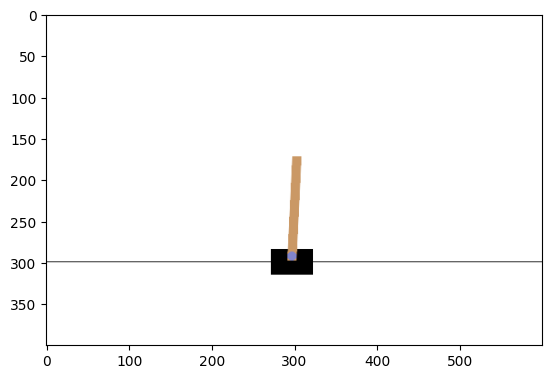

In [60]:
env = gym.make("CartPole-v0", render_mode='rgb_array').env
env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape
if(len(state_dim) == 1):
    state_dim = state_dim[0]
print(state_dim)

plt.imshow(env.render())
plt.show()

In [61]:
class Network(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.inner_network = nn.Sequential(
            nn.Linear(state_dim, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, n_actions))
        
    def forward(self, x):
        if x is not torch.Tensor:
            x = torch.tensor(x)
        return self.inner_network(x)
    
    def get_action(self, x, epsilon = 0):
        if random.random() < epsilon:
            return random.randint(0, n_actions - 1)
        q_vals = self.forward(x)
        return int(torch.argmax(q_vals))
    
device = torch.device('cpu')
network = Network(state_dim, n_actions).to(device)
optimizer = torch.optim.Adam(network.parameters(), lr=1e-4)

In [62]:
s = env.reset()[0]
assert np.shape(network.get_action(s)) == ()

In [63]:
gamma = 0.99

def train_step(model : torch.nn.Module, optimizer : torch.optim.Optimizer, state, next_state, action, reward, done):
    state = torch.tensor([state])
    next_state = torch.tensor([next_state])

    optimizer.zero_grad()

    predicted_qvalues = model(state)
    one_hot = nn.functional.one_hot(torch.tensor([action]), n_actions)
    qvalues_for_actions = torch.sum(predicted_qvalues * one_hot, axis=1)

    with torch.no_grad():
        predicted_next_qvalues = model(next_state)
        predicted_qvalues_for_actions = torch.max(predicted_next_qvalues)
        if done:
            target = torch.tensor([reward])
        else:
            target = torch.tensor([reward]) + gamma * predicted_qvalues_for_actions
    
    loss = nn.functional.mse_loss(qvalues_for_actions, target)
    loss.backward()
    optimizer.step()

In [64]:
def generate_session(env, t_max = 1000, epsilon = 0, train = False):
    if train:
        network.train(True)

    total_reward = 0
    s = env.reset()[0]
    for t in range(t_max):
        a = network.get_action(s, epsilon)
        next_s, r, terminated, truncated, _ = env.step(a)
        done = terminated or truncated
        if train:
            train_step(network, optimizer, s, next_s, a, r, done)
        
        total_reward += r
        s = next_s
        if done:
            break

    if train:
        network.train(False)
    return total_reward

epsilon = 0.5
for i in range(1000):
    session_rewards = [generate_session(env, 500, epsilon, True) for _ in tqdm(range(50), f'Training epoch #{i}\tepsilon = {epsilon:.3f}\t')]   # tqdm is used to track progress
    print(f'\tMean reward = {np.mean(session_rewards):.3f}')
    
    epsilon *= 0.99
    if(epsilon < 1e-4):
        epsilon = 0.1

    if np.mean(session_rewards) > 300:
        print("You won!")
        break

Training epoch #0	epsilon = 0.500	:   0%|          | 0/50 [00:00<?, ?it/s]C:\Users\yaggod\AppData\Local\Temp\ipykernel_1136\2984926389.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x)
Training epoch #0	epsilon = 0.500	: 100%|██████████| 50/50 [00:01<00:00, 40.63it/s]


	Mean reward = 14.800


Training epoch #1	epsilon = 0.495	: 100%|██████████| 50/50 [00:01<00:00, 48.30it/s]


	Mean reward = 12.640


Training epoch #2	epsilon = 0.490	: 100%|██████████| 50/50 [00:01<00:00, 47.79it/s]


...

	Mean reward = 224.840


Training epoch #34	epsilon = 0.355	: 100%|██████████| 50/50 [00:21<00:00,  2.31it/s]


	Mean reward = 216.880


Training epoch #35	epsilon = 0.352	: 100%|██████████| 50/50 [00:28<00:00,  1.75it/s]

	Mean reward = 319.560
You won!
